1.Filtro Bayer

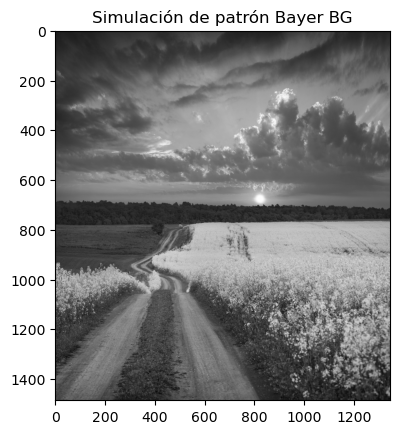

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('imagen.jpg', cv2.IMREAD_GRAYSCALE)

bayer = np.zeros_like(imagen)

bayer[::2, ::2] = imagen[::2, ::2]  
bayer[::2, 1::2] = imagen[::2, 1::2]  
bayer[1::2, ::2] = imagen[1::2, ::2]  
bayer[1::2, 1::2] = imagen[1::2, 1::2]  

plt.imshow(bayer, cmap='gray')
plt.title("Simulación de patrón Bayer BG")
plt.show()

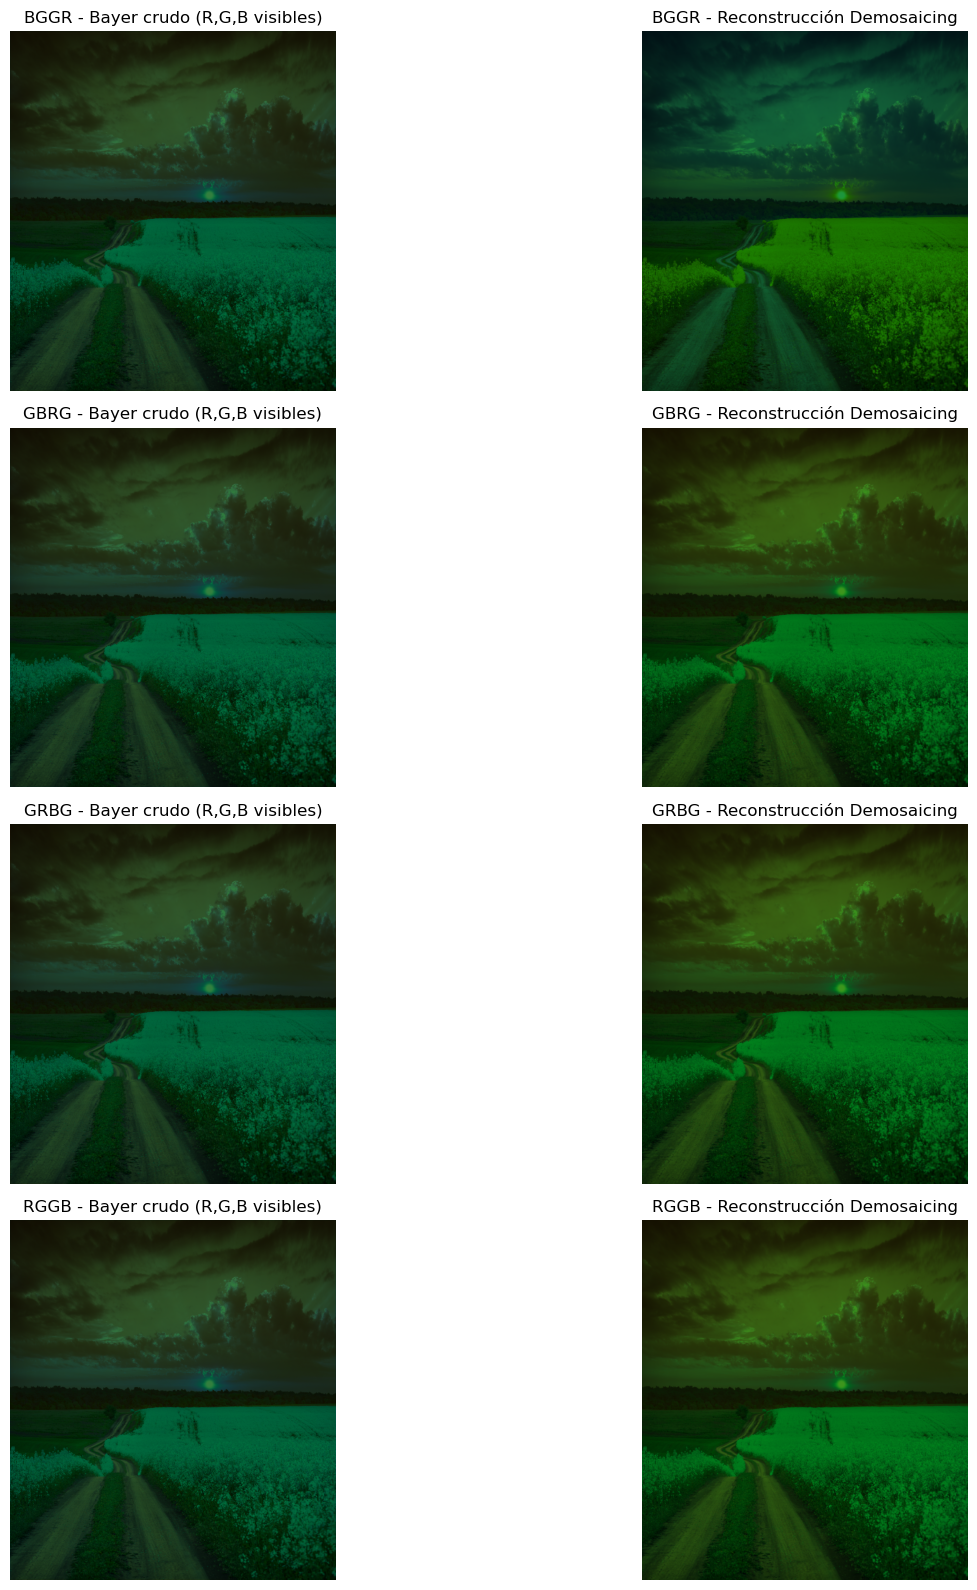

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('imagen.jpg')
if imagen_bgr is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

patterns = ["BGGR", "GBRG", "GRBG", "RGGB"]

def simulate_bayer_rgb(img_rgb, pattern):
    h, w, _ = img_rgb.shape
    bayer = np.zeros_like(img_rgb)
    
    R = img_rgb[:, :, 0]
    G = img_rgb[:, :, 1]
    B = img_rgb[:, :, 2]
    
    if pattern == "BGGR":
        bayer[::2, ::2, 2] = R[::2, ::2]    # Rojo
        bayer[1::2, 1::2, 0] = B[1::2, 1::2]  # Azul
        bayer[::2, 1::2, 1] = G[::2, 1::2]  # Verde
        bayer[1::2, ::2, 1] = G[1::2, ::2]  # Verde
    elif pattern == "GBRG":
        bayer[::2, ::2, 1] = G[::2, ::2]
        bayer[::2, 1::2, 0] = B[::2, 1::2]
        bayer[1::2, ::2, 2] = R[1::2, ::2]
        bayer[1::2, 1::2, 1] = G[1::2, 1::2]
    elif pattern == "GRBG":
        bayer[::2, ::2, 1] = G[::2, ::2]
        bayer[::2, 1::2, 2] = R[::2, 1::2]
        bayer[1::2, ::2, 0] = B[1::2, ::2]
        bayer[1::2, 1::2, 1] = G[1::2, 1::2]
    elif pattern == "RGGB":
        bayer[::2, ::2, 2] = R[::2, ::2]
        bayer[::2, 1::2, 1] = G[::2, 1::2]
        bayer[1::2, ::2, 1] = G[1::2, ::2]
        bayer[1::2, 1::2, 0] = B[1::2, 1::2]
        
    return bayer

plt.figure(figsize=(16, 16))

for i, pattern in enumerate(patterns, 1):
    bayer_rgb = simulate_bayer_rgb(imagen_rgb, pattern)
    
    sensor_gray = cv2.cvtColor(bayer_rgb, cv2.COLOR_RGB2GRAY)
    
    if pattern == "BGGR":
        code = cv2.COLOR_BAYER_BG2BGR
    elif pattern == "GBRG":
        code = cv2.COLOR_BAYER_GB2BGR
    elif pattern == "GRBG":
        code = cv2.COLOR_BAYER_GR2BGR
    else:  # RGGB
        code = cv2.COLOR_BAYER_RG2BGR
    
    img_demosaic = cv2.cvtColor(sensor_gray, code)
    
    plt.subplot(4, 2, 2*i-1)
    plt.imshow(bayer_rgb)
    plt.title(f"{pattern} - Bayer crudo (R,G,B visibles)")
    plt.axis('off')
    
    plt.subplot(4, 2, 2*i)
    plt.imshow(cv2.cvtColor(img_demosaic, cv2.COLOR_BGR2RGB))
    plt.title(f"{pattern} - Reconstrucción Demosaicing")
    plt.axis('off')

plt.tight_layout()
plt.show()

2.Transformación YUV ↔ RGB

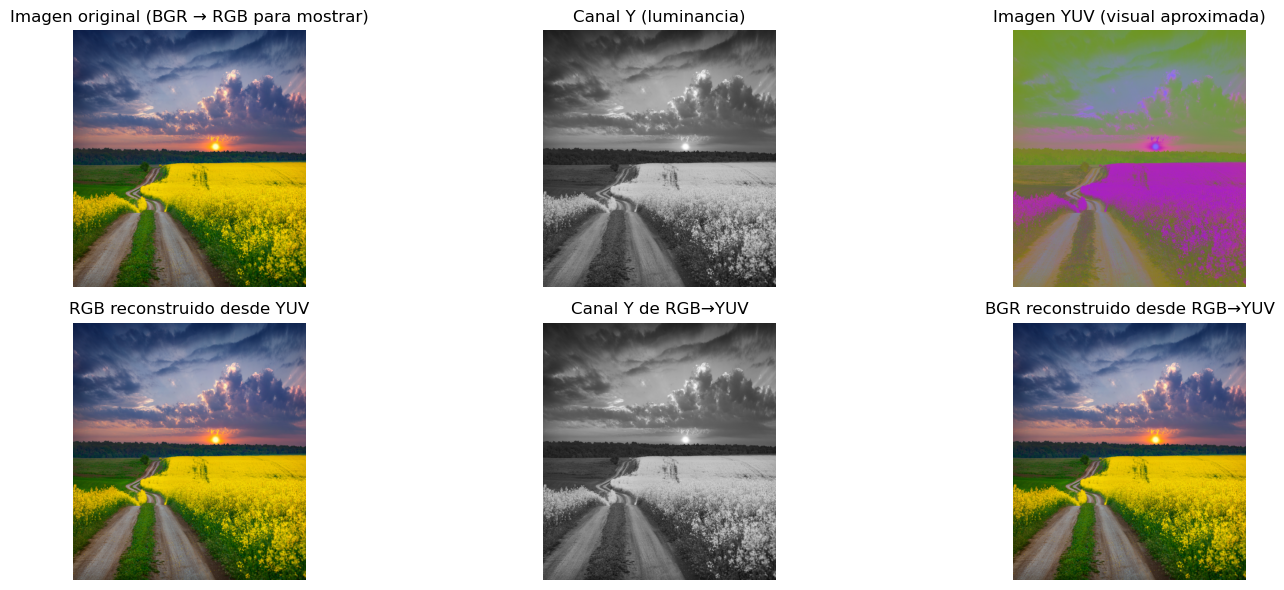

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagen_bgr = cv2.imread("imagen.jpg")
if imagen_bgr is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

imagen_yuv = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2YUV)


imagen_rgb = cv2.cvtColor(imagen_yuv, cv2.COLOR_YUV2RGB)


rgb_to_yuv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YUV)


yuv_to_bgr = cv2.cvtColor(rgb_to_yuv, cv2.COLOR_YUV2BGR)

plt.figure(figsize=(16, 6))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB))
plt.title("Imagen original (BGR → RGB para mostrar)")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(imagen_yuv[:,:,0], cmap='gray')
plt.title("Canal Y (luminancia)")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(cv2.merge([imagen_yuv[:,:,2], imagen_yuv[:,:,1], imagen_yuv[:,:,0]]))  
plt.title("Imagen YUV (visual aproximada)")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(imagen_rgb)
plt.title("RGB reconstruido desde YUV")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(rgb_to_yuv[:,:,0], cmap='gray')
plt.title("Canal Y de RGB→YUV")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(yuv_to_bgr, cv2.COLOR_BGR2RGB))
plt.title("BGR reconstruido desde RGB→YUV")
plt.axis('off')

plt.tight_layout()
plt.show()